# Experiment 1.3.2 — Small temporal CNN on direct 30-channel event representations

This experiment follows Experiments 1.3 / 1.3.1 and asks a different question:

> **After choosing a temporal representation of the 30 unsigned event channels, can a small local temporal model recover discriminative structure that a linear probe cannot?**

The input is still the direct **30-channel unsigned polarity-split weighted event representation** at the dataset-declared sampling rate (expected: 64 Hz). No reconstructed acceleration is used.

The default representations are deliberately small in number:

1. **Raw timestep sequence** — one 64 Hz sample per temporal position.
2. **Fixed ~100 ms bins** — absolute-time event sums.
3. **Fixed 250 ms bins** — the strongest fixed raw scale observed in the initial 1.3.1 split.
4. **Fixed 500 ms bins** — a coarser absolute-time control.
5. **Relative 10-bin sequence** — gesture-progress baseline from Experiment 1.3.

Every representation remains a sequence `[time_bins, 30 channels]`; it is **not flattened before the CNN**. A small shared architecture is used for every condition:

`Conv1d(30→32,k=3,bias=False) → ReLU → Conv1d(32→32,k=3,bias=False) → ReLU → masked global average pooling → Linear(32→classes)`

The CNN is intentionally small so this remains a representation probe rather than a high-capacity end-to-end model benchmark. A Logistic Regression baseline is recomputed on the flattened version of the exact same representation.

### Cross-user protocol

The default protocol uses **5 user-disjoint split seeds**, with **12 train / 4 validation / 4 test users** per split. Within each split, all representations share the same users and the same CNN initialization seed. Validation Balanced Accuracy selects the best epoch; the test split is evaluated only after restoring that validation-selected checkpoint.

### Important interpretation

A CNN improvement over the corresponding Linear probe means the representation contains **local nonlinear/compositional temporal structure** that a global linear readout does not exploit. It does **not** mean the representation itself is linearly separable at the CNN accuracy.


In [1]:
from pathlib import Path
import copy
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root from current working directory")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingRing
PyTorch: 2.11.0+cu128
CUDA available: True


## 1. Configuration

The defaults implement the current plan directly. `FIXED_CNN_DURATIONS_MS` can be extended later, but the primary 1.3.2 comparison intentionally uses only representative scales rather than another dense sweep.


In [ ]:
# -----------------------------------------------------------------------------
# USER CONFIGURATION
# -----------------------------------------------------------------------------
ACTION0_COMBINATION_DIR = REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64"
ACTION1_COMBINATION_DIR = REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64"
DATASET_ROOTS = [
    ACTION0_COMBINATION_DIR / "low-pass/aligned-board-events/segmentation_padded",
    ACTION1_COMBINATION_DIR / "low-pass/aligned-board-events/segmentation_padded",
]

EXPECTED_EVENT_REPRESENTATION = "unsigned"
EXPECTED_EVENT_FEATURE_SCHEMA = "custom_wavelet_polarity_split_abs_events_v1"
EVENT_CHANNEL_COUNT = 30
TOTAL_CHANNEL_COUNT = EVENT_CHANNEL_COUNT + 6
EXPECTED_SAMPLING_RATE_HZ = 64.0

INCLUDED_LABELS: tuple[str, ...] | None = (
    "A", "B", "C", "D", "E", "X", "G", "H", "I", "J", "K", "L"
)

# Cross-user robustness: 12/4/4 users for the current 20-user cohort.
SPLIT_SEEDS = (11, 23, 37, 53, 71)
N_TRAIN_USERS = 12
N_VAL_USERS = 4
N_TEST_USERS = 4

# Representations tested by the same small CNN.
FIXED_CNN_DURATIONS_MS = (100, 250, 500)
RELATIVE_N_BINS = 10

# CNN architecture / optimization.
CNN_CHANNELS = 32
CNN_KERNEL_SIZE = 3
BATCH_SIZE = 64
MAX_EPOCHS = 200
MIN_EPOCHS = 20
EARLY_STOP_PATIENCE = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
MODEL_INIT_SEED = 2026

# Linear baseline on the exact same representations.
LOGREG_MAX_ITER = 5000

# Runtime / output.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PADDING_ZERO_TOL = 1e-12
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts/experiment_1_3_2_fixed_duration_temporal_cnn_probe"
SAVE_CHECKPOINTS = False

print("Roots:", *DATASET_ROOTS, sep="\n - ")
print("Split seeds:", SPLIT_SEEDS)
print("Users per split:", N_TRAIN_USERS, N_VAL_USERS, N_TEST_USERS)
print("Fixed CNN durations (requested ms):", FIXED_CNN_DURATIONS_MS)
print("Device:", DEVICE)


Roots:
 - /home/ted/project/writingRing/outputs/action0_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded
 - /home/ted/project/writingRing/outputs/action1_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded
Split seeds: (11, 23, 37, 53, 71)
Users per split: 12 4 4
Fixed CNN durations (requested ms): (100, 250, 500)
Device: cuda


## 2. Reproducibility helpers

The same CNN initialization seed is reused across representations inside a split. Because the architecture parameter shapes are identical for all temporal lengths, this gives the representations the same initial convolution/head weights. Batch ordering is also deterministic.


In [3]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


seed_everything(MODEL_INIT_SEED)


## 3. Load and validate the 30-channel unsigned event cohort

Only the first 30 event channels are used. The six stored IMU channels are excluded from this experiment.


In [4]:
REQUIRE_RECONSTRUCTION = False

data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=REQUIRE_RECONSTRUCTION,
)


def read_dataset_sampling_rate_hz(data) -> float:
    rates_by_root = {
        str(root): float(metadata.sampling_rate_hz)
        for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True)
    }
    rates = sorted(set(rates_by_root.values()))
    if len(rates) != 1:
        raise ValueError(f"Selected roots must share sampling_rate_hz metadata; got {rates_by_root}")
    rate = rates[0]
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError(f"Invalid sampling rate: {rate!r}")
    return rate


SAMPLING_RATE_HZ = read_dataset_sampling_rate_hz(data)
if not np.isclose(SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ):
    raise ValueError(
        f"Expected {EXPECTED_SAMPLING_RATE_HZ} Hz input; dataset declares {SAMPLING_RATE_HZ} Hz"
    )

for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True):
    raw = metadata.raw
    if raw.get("event_representation") != EXPECTED_EVENT_REPRESENTATION:
        raise ValueError(
            f"{root}: expected event_representation={EXPECTED_EVENT_REPRESENTATION!r}; "
            f"got {raw.get('event_representation')!r}"
        )
    if raw.get("event_feature_schema") != EXPECTED_EVENT_FEATURE_SCHEMA:
        raise ValueError(
            f"{root}: expected event_feature_schema={EXPECTED_EVENT_FEATURE_SCHEMA!r}; "
            f"got {raw.get('event_feature_schema')!r}"
        )
    if raw.get("event_channel_count") != EVENT_CHANNEL_COUNT or metadata.channel_count != TOTAL_CHANNEL_COUNT:
        raise ValueError(
            f"{root}: expected {EVENT_CHANNEL_COUNT} event + 6 IMU = {TOTAL_CHANNEL_COUNT} channels; "
            f"got event_channel_count={raw.get('event_channel_count')!r}, "
            f"channel_count={metadata.channel_count!r}"
        )

for package in data.packages:
    if package.padded_spike_imu.shape[2] != TOTAL_CHANNEL_COUNT:
        raise ValueError(
            f"{package.padded_spike_imu_path}: expected shape[..., {TOTAL_CHANNEL_COUNT}], "
            f"got {package.padded_spike_imu.shape}"
        )
    event_values = np.asarray(package.padded_spike_imu[..., :EVENT_CHANNEL_COUNT])
    if np.any(~np.isfinite(event_values)) or np.any(event_values < 0.0):
        raise ValueError(f"{package.padded_spike_imu_path}: events must be finite and non-negative")

rows = []
keep_labels = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))
for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if keep_labels is not None and label not in keep_labels:
            continue
        rows.append({
            "package_index": package_index,
            "segment_index": segment_index,
            "user": str(package.user),
            "action": str(package.action),
            "label": label,
            "valid_length": int(package.valid_lengths[segment_index]),
            "package_padded_length": int(package.padded_spike_imu.shape[1]),
            "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
        })

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after applying INCLUDED_LABELS")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)
N_CLASSES = len(CLASS_TO_IDX)
GLOBAL_PADDED_LENGTH = int(manifest["package_padded_length"].max())

print(f"Loaded {len(manifest):,} samples from {manifest['user'].nunique()} users")
print("Actions:", sorted(manifest["action"].unique().tolist()))
print("Classes:", N_CLASSES, labels_sorted)
print("Sampling rate:", SAMPLING_RATE_HZ, "Hz")
print("Event channels:", EVENT_CHANNEL_COUNT)
print("Valid-length range:", manifest["valid_length"].min(), "..", manifest["valid_length"].max())
print("Package padded lengths:", sorted(manifest["package_padded_length"].unique().tolist()))
print("Global padded length:", GLOBAL_PADDED_LENGTH)
display(manifest.head())


Loaded 853 samples from 20 users
Actions: ['0', '1']
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 64.0 Hz
Event channels: 30
Valid-length range: 44 .. 247
Package padded lengths: [256]
Global padded length: 256


,package_index,segment_index,user,action,label,valid_length,package_padded_length,sample_id,label_idx
0,0,24,user_0,0,J,72,256,user_0/action_0/24,8
1,0,25,user_0,0,B,128,256,user_0/action_0/25,1
2,0,26,user_0,0,X,106,256,user_0/action_0/26,11
3,0,27,user_0,0,E,122,256,user_0/action_0/27,4
4,0,31,user_0,0,G,124,256,user_0/action_0/31,5


## 4. Padding sanity check

Absolute-time raw/fixed representations assume all stored event values after each `valid_length` are zero. This check prevents padding artifacts from entering the CNN.


In [5]:
def check_event_padding_is_zero(data, df: pd.DataFrame, tol: float = 1e-12) -> pd.DataFrame:
    checks = []
    for row in df.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        T = int(p.padded_spike_imu.shape[1])
        tail = np.asarray(p.padded_spike_imu[i, L:T, :EVENT_CHANNEL_COUNT], dtype=np.float64)
        max_abs_tail = float(np.max(np.abs(tail))) if tail.size else 0.0
        checks.append({
            "sample_id": row.sample_id,
            "valid_length": L,
            "package_padded_length": T,
            "tail_timesteps": max(0, T - L),
            "max_abs_event_in_padding": max_abs_tail,
        })
    return pd.DataFrame(checks)


padding_check = check_event_padding_is_zero(data, manifest, PADDING_ZERO_TOL)
max_padding_value = float(padding_check["max_abs_event_in_padding"].max())
print("Maximum absolute event value after valid_length:", max_padding_value)
if max_padding_value > PADDING_ZERO_TOL:
    display(
        padding_check[padding_check["max_abs_event_in_padding"] > PADDING_ZERO_TOL]
        .sort_values("max_abs_event_in_padding", ascending=False)
        .head(20)
    )
    raise ValueError("Non-zero events found in padding; raw/fixed CNN probes require zero padding")
print("Padding contract verified.")


Maximum absolute event value after valid_length: 0.0
Padding contract verified.


## 5. User-disjoint 12/4/4 split helper

Each split seed independently permutes users. All representations inside that split use the **same users**. For the current 20-user cohort, the expected allocation is exactly 12 train / 4 validation / 4 test users.


In [6]:
def make_user_split(manifest: pd.DataFrame, split_seed: int) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    expected_total = N_TRAIN_USERS + N_VAL_USERS + N_TEST_USERS
    if len(users) != expected_total:
        raise ValueError(
            f"This notebook is configured for {expected_total} users "
            f"({N_TRAIN_USERS}/{N_VAL_USERS}/{N_TEST_USERS}), but found {len(users)}. "
            "Adjust the user-count configuration explicitly."
        )

    rng = np.random.default_rng(derive_seed(split_seed, "user_split"))
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    train_users = set(perm[:N_TRAIN_USERS].tolist())
    val_users = set(perm[N_TRAIN_USERS:N_TRAIN_USERS + N_VAL_USERS].tolist())
    test_users = set(perm[N_TRAIN_USERS + N_VAL_USERS:].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else ("val" if u in val_users else "test")
    )

    split_sets = {
        name: set(out.loc[out.split == name, "user"])
        for name in ("train", "val", "test")
    }
    assert split_sets["train"].isdisjoint(split_sets["val"])
    assert split_sets["train"].isdisjoint(split_sets["test"])
    assert split_sets["val"].isdisjoint(split_sets["test"])

    for split_name in ("train", "val", "test"):
        part = out[out.split == split_name]
        missing = sorted(set(labels_sorted) - set(part["label"].unique().tolist()))
        if missing:
            raise ValueError(
                f"split_seed={split_seed} {split_name} split is missing classes: {missing}. "
                "Choose a different split seed."
            )
    return out


split_review_rows = []
for split_seed in SPLIT_SEEDS:
    sm = make_user_split(manifest, split_seed)
    for split_name in ("train", "val", "test"):
        part = sm[sm.split == split_name]
        split_review_rows.append({
            "split_seed": split_seed,
            "split": split_name,
            "users": part.user.nunique(),
            "samples": len(part),
            "classes_present": part.label.nunique(),
            "user_ids": ",".join(sorted(part.user.unique().tolist())),
        })

split_review = pd.DataFrame(split_review_rows)
display(split_review)


,split_seed,split,users,samples,classes_present,user_ids
0,11,train,12,477,12,"user_0,user_10,user_13,user_15,user_18,user_19..."
1,11,val,4,168,12,"user_11,user_12,user_16,user_9"
2,11,test,4,208,12,"user_1,user_14,user_2,user_3"
3,23,train,12,495,12,"user_0,user_1,user_12,user_13,user_15,user_18,..."
4,23,val,4,181,12,"user_10,user_11,user_14,user_3"
5,23,test,4,177,12,"user_16,user_5,user_6,user_8"
6,37,train,12,519,12,"user_0,user_11,user_12,user_15,user_16,user_18..."
7,37,val,4,176,12,"user_1,user_13,user_20,user_5"
8,37,test,4,158,12,"user_10,user_14,user_4,user_9"
9,53,train,12,514,12,"user_1,user_10,user_12,user_13,user_14,user_15..."


## 6. Representation builders

All builders return:

- `X`: `[N, time_bins, 30]`
- `mask`: `[N, time_bins]`, where `True` marks valid temporal positions
- `y`: class indices

For fixed-duration bins, the last partial valid bin is retained. For the raw representation, one timestep is one temporal position. Relative 10-bin uses each sample's valid prefix and therefore has exactly 10 valid bins for every sample.


In [7]:
def labels_for_df(df: pd.DataFrame) -> np.ndarray:
    return df["label_idx"].to_numpy(dtype=np.int64)


def valid_lengths_for_df(df: pd.DataFrame) -> np.ndarray:
    return df["valid_length"].to_numpy(dtype=np.int64)


def build_global_padded_events(data, df: pd.DataFrame, global_length: int) -> np.ndarray:
    out = np.zeros((len(df), global_length, EVENT_CHANNEL_COUNT), dtype=np.float32)
    for row_index, row in enumerate(df.itertuples(index=False)):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        x = np.asarray(p.padded_spike_imu[i, :, :EVENT_CHANNEL_COUNT], dtype=np.float32)
        if x.shape[0] > global_length:
            raise ValueError(f"Stored padded length {x.shape[0]} exceeds global_length={global_length}")
        out[row_index, :x.shape[0], :] = x
    return out


def raw_sequence_representation(data, df: pd.DataFrame):
    X = build_global_padded_events(data, df, GLOBAL_PADDED_LENGTH)
    lengths = valid_lengths_for_df(df)
    mask = np.arange(GLOBAL_PADDED_LENGTH)[None, :] < lengths[:, None]
    return X, mask, labels_for_df(df)


def duration_ms_to_samples(duration_ms: float, sampling_rate_hz: float) -> int:
    samples = int(np.rint(float(duration_ms) * float(sampling_rate_hz) / 1000.0))
    return max(1, samples)


def fixed_duration_representation(data, df: pd.DataFrame, requested_ms: float):
    samples_per_bin = duration_ms_to_samples(requested_ms, SAMPLING_RATE_HZ)
    X_raw = build_global_padded_events(data, df, GLOBAL_PADDED_LENGTH)
    lengths = valid_lengths_for_df(df)

    n_samples, T, channels = X_raw.shape
    n_bins = int(np.ceil(T / samples_per_bin))
    target_T = n_bins * samples_per_bin
    if target_T > T:
        X_raw = np.pad(X_raw, ((0, 0), (0, target_T - T), (0, 0)), mode="constant")

    X_bins = X_raw.reshape(n_samples, n_bins, samples_per_bin, channels).sum(axis=2)
    valid_bins = np.ceil(lengths / samples_per_bin).astype(np.int64)
    mask = np.arange(n_bins)[None, :] < valid_bins[:, None]

    actual_ms = samples_per_bin / SAMPLING_RATE_HZ * 1000.0
    meta = {
        "requested_duration_ms": float(requested_ms),
        "samples_per_bin": int(samples_per_bin),
        "actual_duration_ms": float(actual_ms),
        "n_time_bins": int(n_bins),
    }
    return X_bins.astype(np.float32), mask, labels_for_df(df), meta


def relative_progress_representation(data, df: pd.DataFrame, n_bins: int = RELATIVE_N_BINS):
    features = []
    for row in df.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        if n_bins > L:
            raise ValueError(f"n_bins={n_bins} exceeds valid_length={L} for {row.sample_id}")
        x = np.asarray(p.padded_spike_imu[i, :L, :EVENT_CHANNEL_COUNT], dtype=np.float32)
        chunks = np.array_split(x, n_bins, axis=0)
        features.append(np.stack([chunk.sum(axis=0) for chunk in chunks], axis=0))
    X = np.stack(features).astype(np.float32)
    mask = np.ones((len(df), n_bins), dtype=bool)
    meta = {
        "requested_duration_ms": np.nan,
        "samples_per_bin": np.nan,
        "actual_duration_ms": np.nan,
        "n_time_bins": int(n_bins),
    }
    return X, mask, labels_for_df(df), meta


def build_representation(data, df: pd.DataFrame, representation: str):
    if representation == "raw_timestep":
        X, mask, y = raw_sequence_representation(data, df)
        meta = {
            "requested_duration_ms": 1000.0 / SAMPLING_RATE_HZ,
            "samples_per_bin": 1,
            "actual_duration_ms": 1000.0 / SAMPLING_RATE_HZ,
            "n_time_bins": GLOBAL_PADDED_LENGTH,
        }
        return X, mask, y, meta
    if representation.startswith("fixed_") and representation.endswith("ms"):
        requested_ms = float(representation.removeprefix("fixed_").removesuffix("ms"))
        return fixed_duration_representation(data, df, requested_ms)
    if representation == "relative_10bin":
        return relative_progress_representation(data, df, RELATIVE_N_BINS)
    raise ValueError(f"Unknown representation: {representation}")


REPRESENTATIONS = (
    "raw_timestep",
    *tuple(f"fixed_{int(ms)}ms" for ms in FIXED_CNN_DURATIONS_MS),
    "relative_10bin",
)

print("Representations:", REPRESENTATIONS)


Representations: ('raw_timestep', 'fixed_100ms', 'fixed_250ms', 'fixed_500ms', 'relative_10bin')


## 7. Train-only channel scaling for CNN inputs

The CNN uses **scale-only** normalization: each event channel is divided by its train-set RMS over valid temporal positions. No mean is subtracted, so genuine zero-event / padding positions remain exactly zero. This stabilizes optimization without converting padding into non-zero values.


In [8]:
def fit_channel_rms_scale(X_train: np.ndarray, mask_train: np.ndarray) -> np.ndarray:
    X = np.asarray(X_train, dtype=np.float64)
    mask = np.asarray(mask_train, dtype=bool)
    valid = X[mask]  # [total_valid_positions, channels]
    if valid.size == 0:
        raise ValueError("No valid training positions available for channel scaling")
    rms = np.sqrt(np.mean(valid * valid, axis=0))
    rms[~np.isfinite(rms)] = 1.0
    rms[rms < 1e-8] = 1.0
    return rms.astype(np.float32)


def apply_channel_scale(X: np.ndarray, scale: np.ndarray, mask: np.ndarray) -> np.ndarray:
    out = np.asarray(X, dtype=np.float32) / scale.reshape(1, 1, -1)
    out = out.copy()
    out[~np.asarray(mask, dtype=bool)] = 0.0
    return out


## 8. Small temporal CNN

`Conv1d` slides only along the representation's temporal/bin axis. The 30 event channels are input channels. Masked global average pooling excludes right-padding positions from the readout.

Because the same `kernel_size=3` is used for every representation, its **physical** receptive field changes with bin duration. This is intentional for this representation-level comparison, but it should not be interpreted as a controlled sweep of CNN physical receptive field.


In [9]:
class SmallTemporalCNN(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.conv1 = nn.Conv1d(
            EVENT_CHANNEL_COUNT,
            CNN_CHANNELS,
            kernel_size=CNN_KERNEL_SIZE,
            padding=CNN_KERNEL_SIZE // 2,
            bias=False,
        )
        self.conv2 = nn.Conv1d(
            CNN_CHANNELS,
            CNN_CHANNELS,
            kernel_size=CNN_KERNEL_SIZE,
            padding=CNN_KERNEL_SIZE // 2,
            bias=False,
        )
        self.act = nn.ReLU()
        self.head = nn.Linear(CNN_CHANNELS, n_classes)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # x: [B, T, 30], mask: [B, T]
        m = mask[:, None, :].to(dtype=x.dtype)
        h = x.transpose(1, 2) * m
        h = self.act(self.conv1(h)) * m
        h = self.act(self.conv2(h)) * m
        denom = m.sum(dim=2).clamp_min(1.0)
        pooled = (h * m).sum(dim=2) / denom
        return self.head(pooled)


model_preview = SmallTemporalCNN(N_CLASSES)
print(model_preview)
print("Trainable parameters:", sum(p.numel() for p in model_preview.parameters() if p.requires_grad))


SmallTemporalCNN(
  (conv1): Conv1d(30, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (act): ReLU()
  (head): Linear(in_features=32, out_features=12, bias=True)
)
Trainable parameters: 6348


## 9. Metrics, deterministic loaders, and training loop

The loss is ordinary multiclass Cross Entropy. Model selection uses **validation Balanced Accuracy**, not training loss and not test performance. The best validation checkpoint is restored before test evaluation.


In [10]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def make_loader(X, mask, y, *, batch_size: int, shuffle: bool, seed: int):
    ds = TensorDataset(
        torch.from_numpy(np.asarray(X, dtype=np.float32)),
        torch.from_numpy(np.asarray(mask, dtype=bool)),
        torch.from_numpy(np.asarray(y, dtype=np.int64)),
    )
    generator = torch.Generator()
    generator.manual_seed(int(seed))
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator if shuffle else None,
    )


@torch.no_grad()
def evaluate_cnn(model, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0
    y_true = []
    y_pred = []
    criterion = nn.CrossEntropyLoss(reduction="sum")

    for xb, mb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        mb = mb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        logits = model(xb, mb)
        loss = criterion(logits, yb)
        total_loss += float(loss.item())
        total_n += int(yb.numel())
        y_true.append(yb.cpu().numpy())
        y_pred.append(logits.argmax(dim=1).cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return {
        "loss": total_loss / max(total_n, 1),
        **classification_metrics(y_true, y_pred),
    }


def train_cnn(
    X_train, mask_train, y_train,
    X_val, mask_val, y_val,
    X_test, mask_test, y_test,
    *, model_seed: int,
):
    seed_everything(model_seed)
    model = SmallTemporalCNN(N_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss()

    train_loader = make_loader(
        X_train, mask_train, y_train,
        batch_size=BATCH_SIZE, shuffle=True,
        seed=derive_seed(model_seed, "train_loader"),
    )
    train_eval_loader = make_loader(
        X_train, mask_train, y_train,
        batch_size=BATCH_SIZE, shuffle=False, seed=model_seed,
    )
    val_loader = make_loader(
        X_val, mask_val, y_val,
        batch_size=BATCH_SIZE, shuffle=False, seed=model_seed,
    )
    test_loader = make_loader(
        X_test, mask_test, y_test,
        batch_size=BATCH_SIZE, shuffle=False, seed=model_seed,
    )

    history = []
    best_state = None
    best_epoch = None
    best_val_ba = -np.inf
    stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        running_n = 0

        for xb, mb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            mb = mb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb, mb)
            loss = criterion(logits, yb)
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

            running_loss += float(loss.item()) * int(yb.numel())
            running_n += int(yb.numel())

        train_metrics = evaluate_cnn(model, train_eval_loader)
        val_metrics = evaluate_cnn(model, val_loader)
        history.append({
            "epoch": epoch,
            "optimization_train_loss": running_loss / max(running_n, 1),
            "train_loss": train_metrics["loss"],
            "train_balanced_accuracy": train_metrics["balanced_accuracy"],
            "val_loss": val_metrics["loss"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        })

        improved = val_metrics["balanced_accuracy"] > best_val_ba + 1e-12
        if improved:
            best_val_ba = float(val_metrics["balanced_accuracy"])
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch >= MIN_EPOCHS and stale_epochs >= EARLY_STOP_PATIENCE:
            break

    if best_state is None:
        raise RuntimeError("Training finished without recording a validation checkpoint")

    model.load_state_dict(best_state)
    train_best = evaluate_cnn(model, train_eval_loader)
    val_best = evaluate_cnn(model, val_loader)
    test_best = evaluate_cnn(model, test_loader)

    return model, pd.DataFrame(history), {
        "best_epoch": int(best_epoch),
        "train": train_best,
        "val": val_best,
        "test": test_best,
    }


## 10. Matching Linear baseline

For each representation and user split, the exact same temporal tensor is flattened and passed to a train-standardized multinomial Logistic Regression. This provides the direct `CNN − Linear` comparison.


In [11]:
def standardize_from_train(X_train, *others):
    X_train = np.asarray(X_train, dtype=np.float64)
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std[std < 1e-8] = 1.0
    transformed = [(X_train - mean) / std]
    transformed.extend((np.asarray(X, dtype=np.float64) - mean) / std for X in others)
    return tuple(transformed)


def evaluate_linear_baseline(X_train, y_train, X_val, y_val, X_test, y_test, *, seed: int):
    Xtr = np.asarray(X_train).reshape(len(X_train), -1)
    Xva = np.asarray(X_val).reshape(len(X_val), -1)
    Xte = np.asarray(X_test).reshape(len(X_test), -1)
    Xtr, Xva, Xte = standardize_from_train(Xtr, Xva, Xte)

    model = LogisticRegression(
        max_iter=LOGREG_MAX_ITER,
        random_state=seed,
        solver="lbfgs",
    )
    model.fit(Xtr, y_train)

    out = {}
    for split_name, X_eval, y_eval in (("val", Xva, y_val), ("test", Xte, y_test)):
        pred = model.predict(X_eval)
        out[split_name] = classification_metrics(y_eval, pred)
    return out


## 11. Run 5 user splits × 5 temporal representations

This is the main experiment. For a given split, the same `model_seed` is used for every representation. CNN channel scaling is fitted separately per representation using only the training users.


In [12]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
if SAVE_CHECKPOINTS:
    (RESULTS_DIR / "checkpoints").mkdir(parents=True, exist_ok=True)

cnn_rows = []
linear_rows = []
history_frames = []
representation_design_rows = []

for split_seed in SPLIT_SEEDS:
    print("=" * 110)
    print("USER SPLIT SEED:", split_seed)
    split_manifest = make_user_split(manifest, split_seed)
    train_df = split_manifest[split_manifest.split == "train"].copy()
    val_df = split_manifest[split_manifest.split == "val"].copy()
    test_df = split_manifest[split_manifest.split == "test"].copy()

    # Same parameter initialization and batch-order seed across representations in this split.
    model_seed = derive_seed(MODEL_INIT_SEED, split_seed, "shared_cnn_init")

    for representation in REPRESENTATIONS:
        print("-" * 110)
        print("REPRESENTATION:", representation)

        Xtr, Mtr, ytr, meta = build_representation(data, train_df, representation)
        Xva, Mva, yva, meta_val = build_representation(data, val_df, representation)
        Xte, Mte, yte, meta_test = build_representation(data, test_df, representation)
        for other_meta in (meta_val, meta_test):
            for key in ("samples_per_bin", "actual_duration_ms", "n_time_bins"):
                a, b = meta[key], other_meta[key]
                if pd.isna(a) and pd.isna(b):
                    continue
                if not np.isclose(float(a), float(b)):
                    raise ValueError(
                        f"Representation metadata mismatch for {representation}: {key}={a!r} vs {b!r}"
                    )

        scale = fit_channel_rms_scale(Xtr, Mtr)
        Xtr_cnn = apply_channel_scale(Xtr, scale, Mtr)
        Xva_cnn = apply_channel_scale(Xva, scale, Mva)
        Xte_cnn = apply_channel_scale(Xte, scale, Mte)

        model, history, cnn_metrics = train_cnn(
            Xtr_cnn, Mtr, ytr,
            Xva_cnn, Mva, yva,
            Xte_cnn, Mte, yte,
            model_seed=model_seed,
        )

        history = history.assign(
            split_seed=split_seed,
            representation=representation,
            requested_duration_ms=meta["requested_duration_ms"],
            actual_duration_ms=meta["actual_duration_ms"],
            n_time_bins=meta["n_time_bins"],
        )
        history_frames.append(history)

        cnn_rows.append({
            "experiment": "experiment_1_3_2",
            "split_seed": split_seed,
            "model_seed": model_seed,
            "model": "small_temporal_cnn",
            "representation": representation,
            **meta,
            "best_epoch": cnn_metrics["best_epoch"],
            "train_balanced_accuracy": cnn_metrics["train"]["balanced_accuracy"],
            "val_balanced_accuracy": cnn_metrics["val"]["balanced_accuracy"],
            "val_accuracy": cnn_metrics["val"]["accuracy"],
            "val_macro_f1": cnn_metrics["val"]["macro_f1"],
            "test_balanced_accuracy": cnn_metrics["test"]["balanced_accuracy"],
            "test_accuracy": cnn_metrics["test"]["accuracy"],
            "test_macro_f1": cnn_metrics["test"]["macro_f1"],
        })

        linear_metrics = evaluate_linear_baseline(
            Xtr, ytr, Xva, yva, Xte, yte,
            seed=derive_seed(split_seed, representation, "linear"),
        )
        linear_rows.append({
            "experiment": "experiment_1_3_2",
            "split_seed": split_seed,
            "model": "linear",
            "representation": representation,
            **meta,
            "val_balanced_accuracy": linear_metrics["val"]["balanced_accuracy"],
            "val_accuracy": linear_metrics["val"]["accuracy"],
            "val_macro_f1": linear_metrics["val"]["macro_f1"],
            "test_balanced_accuracy": linear_metrics["test"]["balanced_accuracy"],
            "test_accuracy": linear_metrics["test"]["accuracy"],
            "test_macro_f1": linear_metrics["test"]["macro_f1"],
        })

        representation_design_rows.append({
            "split_seed": split_seed,
            "representation": representation,
            **meta,
            "cnn_input_shape_train": str(tuple(Xtr.shape)),
            "valid_bins_train_mean": float(Mtr.sum(axis=1).mean()),
            "valid_bins_train_min": int(Mtr.sum(axis=1).min()),
            "valid_bins_train_max": int(Mtr.sum(axis=1).max()),
        })

        print(
            f"best epoch={cnn_metrics['best_epoch']:3d} | "
            f"CNN val BA={cnn_metrics['val']['balanced_accuracy']:.4f} "
            f"test BA={cnn_metrics['test']['balanced_accuracy']:.4f} | "
            f"Linear test BA={linear_metrics['test']['balanced_accuracy']:.4f}"
        )

        if SAVE_CHECKPOINTS:
            torch.save(
                {
                    "state_dict": model.state_dict(),
                    "split_seed": split_seed,
                    "model_seed": model_seed,
                    "representation": representation,
                    "representation_meta": meta,
                    "class_to_idx": CLASS_TO_IDX,
                    "channel_rms_scale": scale,
                },
                RESULTS_DIR / "checkpoints" / f"split_{split_seed}_{representation}.pt",
            )

cnn_results = pd.DataFrame(cnn_rows)
linear_results = pd.DataFrame(linear_rows)
training_history = pd.concat(history_frames, ignore_index=True)
representation_design = pd.DataFrame(representation_design_rows)

cnn_results.to_csv(RESULTS_DIR / "experiment_1_3_2_cnn_results.csv", index=False)
linear_results.to_csv(RESULTS_DIR / "experiment_1_3_2_linear_results.csv", index=False)
training_history.to_csv(RESULTS_DIR / "experiment_1_3_2_training_history.csv", index=False)
representation_design.to_csv(RESULTS_DIR / "experiment_1_3_2_representation_design.csv", index=False)
split_review.to_csv(RESULTS_DIR / "experiment_1_3_2_user_splits.csv", index=False)
padding_check.to_csv(RESULTS_DIR / "experiment_1_3_2_padding_check.csv", index=False)

print("Saved artifacts to:", RESULTS_DIR)
display(cnn_results)
display(linear_results)


USER SPLIT SEED: 11
--------------------------------------------------------------------------------------------------------------
REPRESENTATION: raw_timestep


/tmp/ipykernel_44904/3832125085.py:13: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.from_numpy(np.asarray(y, dtype=np.int64)),


best epoch= 27 | CNN val BA=0.2442 test BA=0.2620 | Linear test BA=0.2872
--------------------------------------------------------------------------------------------------------------
REPRESENTATION: fixed_100ms
best epoch=144 | CNN val BA=0.4294 test BA=0.5715 | Linear test BA=0.5196
--------------------------------------------------------------------------------------------------------------
REPRESENTATION: fixed_250ms
best epoch= 79 | CNN val BA=0.5063 test BA=0.5134 | Linear test BA=0.6832
--------------------------------------------------------------------------------------------------------------
REPRESENTATION: fixed_500ms
best epoch= 96 | CNN val BA=0.5590 test BA=0.6278 | Linear test BA=0.6477
--------------------------------------------------------------------------------------------------------------
REPRESENTATION: relative_10bin
best epoch=138 | CNN val BA=0.5594 test BA=0.6237 | Linear test BA=0.8178
USER SPLIT SEED: 23
---------------------------------------------------

,experiment,split_seed,model_seed,model,representation,requested_duration_ms,samples_per_bin,actual_duration_ms,n_time_bins,best_epoch,train_balanced_accuracy,val_balanced_accuracy,val_accuracy,val_macro_f1,test_balanced_accuracy,test_accuracy,test_macro_f1
0,experiment_1_3_2,11,1106383512,small_temporal_cnn,raw_timestep,15.625,1.0,15.625,256,27,0.285122,0.244231,0.255952,0.192681,0.261976,0.283654,0.181174
1,experiment_1_3_2,11,1106383512,small_temporal_cnn,fixed_100ms,100.000,6.0,93.750,43,144,0.882651,0.429422,0.446429,0.420453,0.571541,0.581731,0.568370
2,experiment_1_3_2,11,1106383512,small_temporal_cnn,fixed_250ms,250.000,16.0,250.000,16,79,0.767809,0.506342,0.517857,0.491991,0.513426,0.528846,0.508445
3,experiment_1_3_2,11,1106383512,small_temporal_cnn,fixed_500ms,500.000,32.0,500.000,8,96,0.883568,0.559047,0.577381,0.560694,0.627751,0.634615,0.627854
4,experiment_1_3_2,11,1106383512,small_temporal_cnn,relative_10bin,NaN,NaN,NaN,10,138,0.964072,0.559394,0.565476,0.556749,0.623672,0.634615,0.629202
5,experiment_1_3_2,23,2762020400,small_temporal_cnn,raw_timestep,15.625,1.0,15.625,256,171,0.672759,0.431699,0.441989,0.409402,0.325240,0.344633,0.317061
6,experiment_1_3_2,23,2762020400,small_temporal_cnn,fixed_100ms,100.000,6.0,93.750,43,102,0.805687,0.600126,0.602210,0.591590,0.436773,0.446328,0.434360
7,experiment_1_3_2,23,2762020400,small_temporal_cnn,fixed_250ms,250.000,16.0,250.000,16,142,0.956035,0.617849,0.618785,0.615030,0.534661,0.548023,0.547779
8,experiment_1_3_2,23,2762020400,small_temporal_cnn,fixed_500ms,500.000,32.0,500.000,8,78,0.837065,0.625297,0.629834,0.614591,0.560927,0.564972,0.571366
9,experiment_1_3_2,23,2762020400,small_temporal_cnn,relative_10bin,NaN,NaN,NaN,10,149,0.980581,0.667254,0.662983,0.669718,0.548691,0.559322,0.553922


,experiment,split_seed,model,representation,requested_duration_ms,samples_per_bin,actual_duration_ms,n_time_bins,val_balanced_accuracy,val_accuracy,val_macro_f1,test_balanced_accuracy,test_accuracy,test_macro_f1
0,experiment_1_3_2,11,linear,raw_timestep,15.625,1.0,15.625,256,0.265274,0.279762,0.242679,0.287241,0.298077,0.280478
1,experiment_1_3_2,11,linear,fixed_100ms,100.000,6.0,93.750,43,0.363675,0.375000,0.354144,0.519553,0.528846,0.522997
2,experiment_1_3_2,11,linear,fixed_250ms,250.000,16.0,250.000,16,0.451709,0.458333,0.446482,0.683184,0.687500,0.682091
3,experiment_1_3_2,11,linear,fixed_500ms,500.000,32.0,500.000,8,0.456670,0.458333,0.436451,0.647699,0.644231,0.644217
4,experiment_1_3_2,11,linear,relative_10bin,NaN,NaN,NaN,10,0.529907,0.547619,0.526575,0.817824,0.817308,0.815073
5,experiment_1_3_2,23,linear,raw_timestep,15.625,1.0,15.625,256,0.277067,0.281768,0.281144,0.328467,0.344633,0.321560
6,experiment_1_3_2,23,linear,fixed_100ms,100.000,6.0,93.750,43,0.482684,0.486188,0.468772,0.482232,0.497175,0.489304
7,experiment_1_3_2,23,linear,fixed_250ms,250.000,16.0,250.000,16,0.618938,0.618785,0.602306,0.537563,0.553672,0.546811
8,experiment_1_3_2,23,linear,fixed_500ms,500.000,32.0,500.000,8,0.540864,0.541436,0.523058,0.571126,0.587571,0.577192
9,experiment_1_3_2,23,linear,relative_10bin,NaN,NaN,NaN,10,0.686616,0.690608,0.692154,0.683647,0.694915,0.700284


## 12. Cross-split summary — mean ± SD

The primary result is the cross-user **test Balanced Accuracy mean ± SD across the 5 split seeds**. This is more meaningful than repeating deterministic probes on one fixed user split.


In [13]:
def summarize_model_results(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    return (
        df.groupby("representation", as_index=False)
        .agg(
            n_splits=("split_seed", "nunique"),
            mean_test_ba=("test_balanced_accuracy", "mean"),
            sd_test_ba=("test_balanced_accuracy", "std"),
            mean_test_accuracy=("test_accuracy", "mean"),
            sd_test_accuracy=("test_accuracy", "std"),
            mean_test_macro_f1=("test_macro_f1", "mean"),
            sd_test_macro_f1=("test_macro_f1", "std"),
            mean_val_ba=("val_balanced_accuracy", "mean"),
            sd_val_ba=("val_balanced_accuracy", "std"),
        )
        .assign(model=model_name)
    )


cnn_summary = summarize_model_results(cnn_results, "small_temporal_cnn")
linear_summary = summarize_model_results(linear_results, "linear")
summary = pd.concat([cnn_summary, linear_summary], ignore_index=True)
summary.to_csv(RESULTS_DIR / "experiment_1_3_2_cross_split_summary.csv", index=False)

display(summary.sort_values(["model", "mean_test_ba"], ascending=[True, False]))


,representation,n_splits,mean_test_ba,sd_test_ba,mean_test_accuracy,sd_test_accuracy,mean_test_macro_f1,sd_test_macro_f1,mean_val_ba,sd_val_ba,model
9,relative_10bin,5,0.714740,0.077896,0.721352,0.069007,0.716394,0.075030,0.716129,0.117610,linear
7,fixed_500ms,5,0.603766,0.034391,0.603931,0.030439,0.596883,0.031927,0.577183,0.078561,linear
6,fixed_250ms,5,0.584882,0.084178,0.590869,0.079441,0.583892,0.084243,0.595559,0.081822,linear
5,fixed_100ms,5,0.496957,0.027172,0.503788,0.025977,0.495766,0.031985,0.499215,0.082931,linear
8,raw_timestep,5,0.305198,0.029454,0.316778,0.032361,0.298180,0.034587,0.294082,0.043433,linear
4,relative_10bin,5,0.588955,0.037891,0.601870,0.039428,0.590394,0.037121,0.652629,0.069358,small_temporal_cnn
2,fixed_500ms,5,0.563154,0.042308,0.571294,0.040269,0.563542,0.044291,0.620429,0.040245,small_temporal_cnn
1,fixed_250ms,5,0.518211,0.023598,0.527913,0.024392,0.520275,0.032466,0.611235,0.077949,small_temporal_cnn
0,fixed_100ms,5,0.473533,0.067849,0.482779,0.067860,0.468381,0.073613,0.546292,0.079524,small_temporal_cnn
3,raw_timestep,5,0.311497,0.056738,0.326853,0.058215,0.275576,0.075763,0.399980,0.096657,small_temporal_cnn


## 13. Paired CNN gain over Linear

Because every representation is evaluated on exactly the same split seed, the most informative comparison is the **paired** difference:

`test BA gain = CNN test BA − Linear test BA`.


In [14]:
paired = cnn_results.merge(
    linear_results,
    on=["experiment", "split_seed", "representation"],
    suffixes=("_cnn", "_linear"),
)
paired["test_ba_gain_cnn_minus_linear"] = (
    paired["test_balanced_accuracy_cnn"] - paired["test_balanced_accuracy_linear"]
)
paired["val_ba_gain_cnn_minus_linear"] = (
    paired["val_balanced_accuracy_cnn"] - paired["val_balanced_accuracy_linear"]
)

gain_summary = (
    paired.groupby("representation", as_index=False)
    .agg(
        mean_test_ba_gain=("test_ba_gain_cnn_minus_linear", "mean"),
        sd_test_ba_gain=("test_ba_gain_cnn_minus_linear", "std"),
        mean_val_ba_gain=("val_ba_gain_cnn_minus_linear", "mean"),
        sd_val_ba_gain=("val_ba_gain_cnn_minus_linear", "std"),
    )
)
paired.to_csv(RESULTS_DIR / "experiment_1_3_2_paired_results.csv", index=False)
gain_summary.to_csv(RESULTS_DIR / "experiment_1_3_2_cnn_minus_linear_gain.csv", index=False)

display(gain_summary.sort_values("mean_test_ba_gain", ascending=False))


,representation,mean_test_ba_gain,sd_test_ba_gain,mean_val_ba_gain,sd_val_ba_gain
3,raw_timestep,0.006300,0.051960,0.105898,0.072328
0,fixed_100ms,-0.023424,0.045500,0.047077,0.052426
2,fixed_500ms,-0.040612,0.041608,0.043246,0.046922
1,fixed_250ms,-0.066671,0.087745,0.015675,0.059136
4,relative_10bin,-0.125784,0.053152,-0.063500,0.083627


## 14. Visualization — cross-split test BA

This figure compares Linear and CNN performance on the same five temporal representations. Error bars are SD across user split seeds.


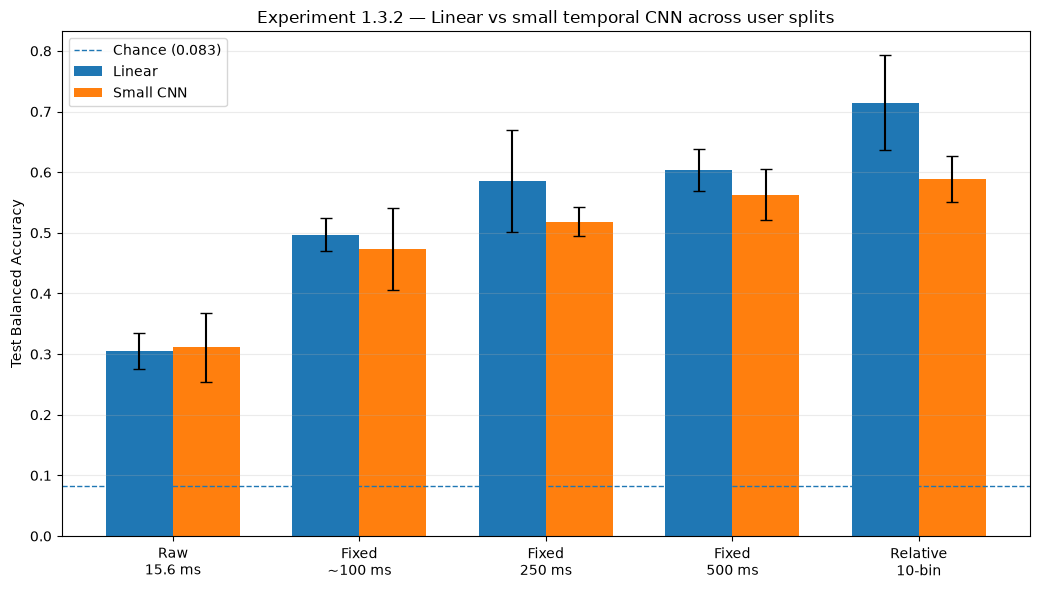

In [15]:
representation_order = list(REPRESENTATIONS)
label_map = {
    "raw_timestep": f"Raw\n{1000.0 / SAMPLING_RATE_HZ:.1f} ms",
    "fixed_100ms": "Fixed\n~100 ms",
    "fixed_250ms": "Fixed\n250 ms",
    "fixed_500ms": "Fixed\n500 ms",
    "relative_10bin": "Relative\n10-bin",
}

x = np.arange(len(representation_order), dtype=float)
width = 0.36
fig, ax = plt.subplots(figsize=(10.5, 6.0))

for offset, model_name, sdf in (
    (-width / 2, "Linear", linear_summary),
    (+width / 2, "Small CNN", cnn_summary),
):
    ordered = sdf.set_index("representation").loc[representation_order]
    ax.bar(
        x + offset,
        ordered["mean_test_ba"].to_numpy(),
        width=width,
        yerr=ordered["sd_test_ba"].to_numpy(),
        capsize=4,
        label=model_name,
    )

ax.axhline(1.0 / N_CLASSES, linestyle="--", linewidth=1.0, label=f"Chance ({1.0 / N_CLASSES:.3f})")
ax.set_xticks(x)
ax.set_xticklabels([label_map.get(r, r) for r in representation_order])
ax.set_ylabel("Test Balanced Accuracy")
ax.set_title("Experiment 1.3.2 — Linear vs small temporal CNN across user splits")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 15. Visualization — paired CNN gain

Positive values indicate that local nonlinear temporal modeling adds information beyond the flattened Linear probe for that representation.


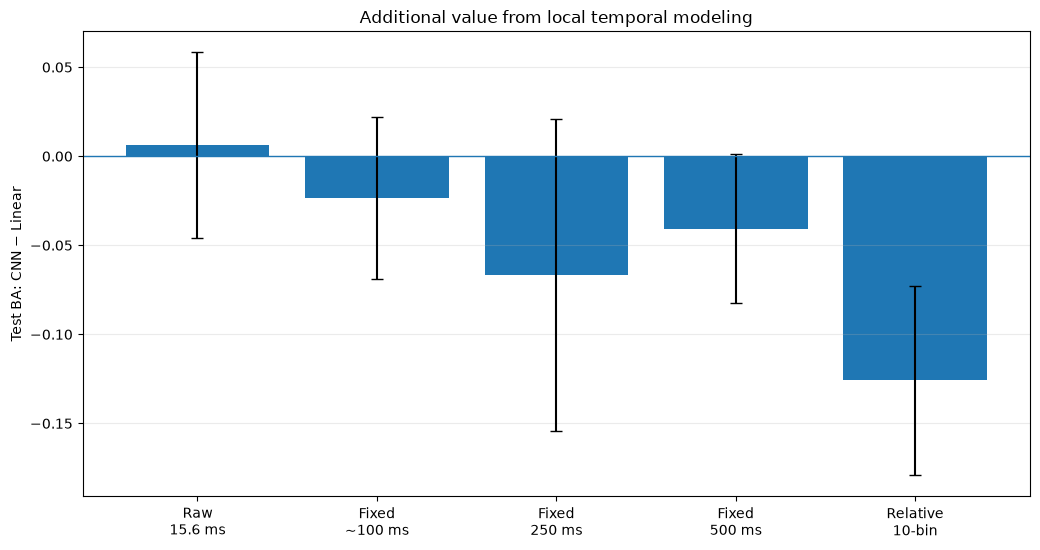

In [16]:
ordered_gain = gain_summary.set_index("representation").loc[representation_order]
fig, ax = plt.subplots(figsize=(10.5, 5.6))
ax.bar(
    np.arange(len(representation_order)),
    ordered_gain["mean_test_ba_gain"].to_numpy(),
    yerr=ordered_gain["sd_test_ba_gain"].to_numpy(),
    capsize=4,
)
ax.axhline(0.0, linewidth=1.0)
ax.set_xticks(np.arange(len(representation_order)))
ax.set_xticklabels([label_map.get(r, r) for r in representation_order])
ax.set_ylabel("Test BA: CNN − Linear")
ax.set_title("Additional value from local temporal modeling")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 16. Validation BA vs epoch

One plot is produced per user split. All five representations share the same split and initialization seed within that figure. The curves make overfitting / convergence differences visible rather than reporting only the selected checkpoint.


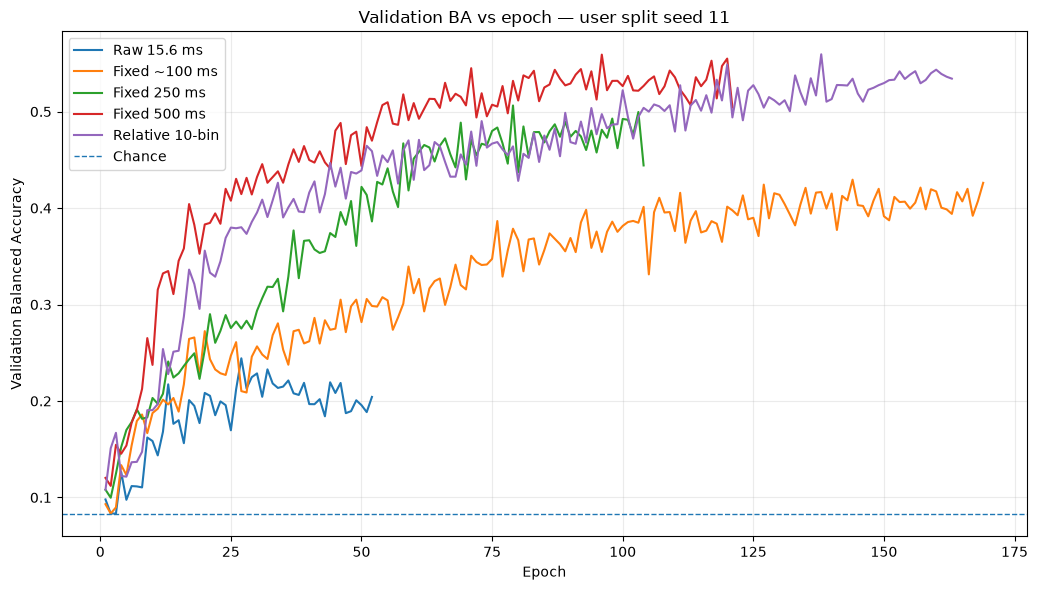

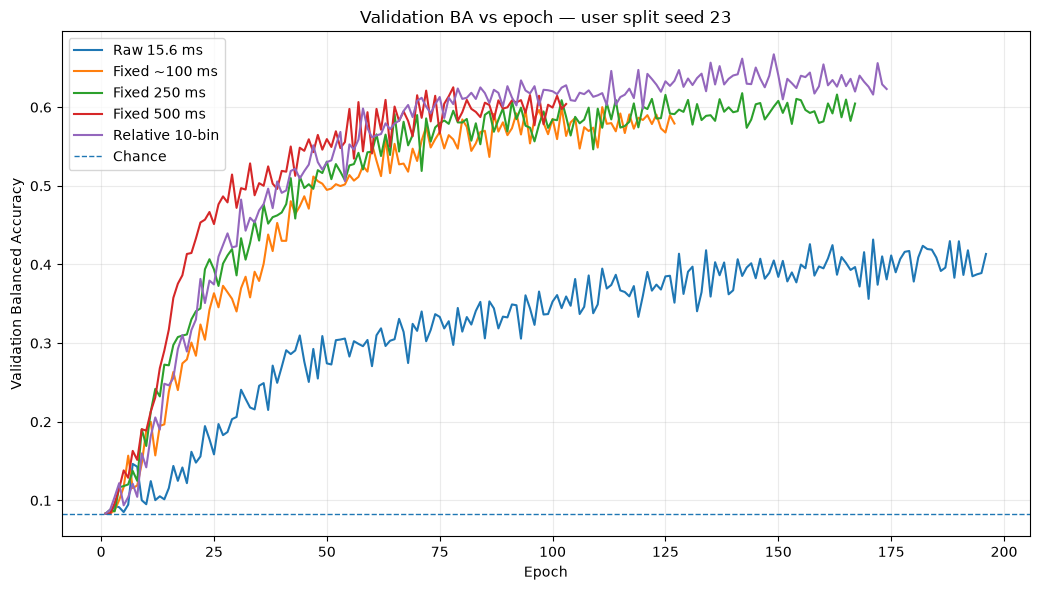

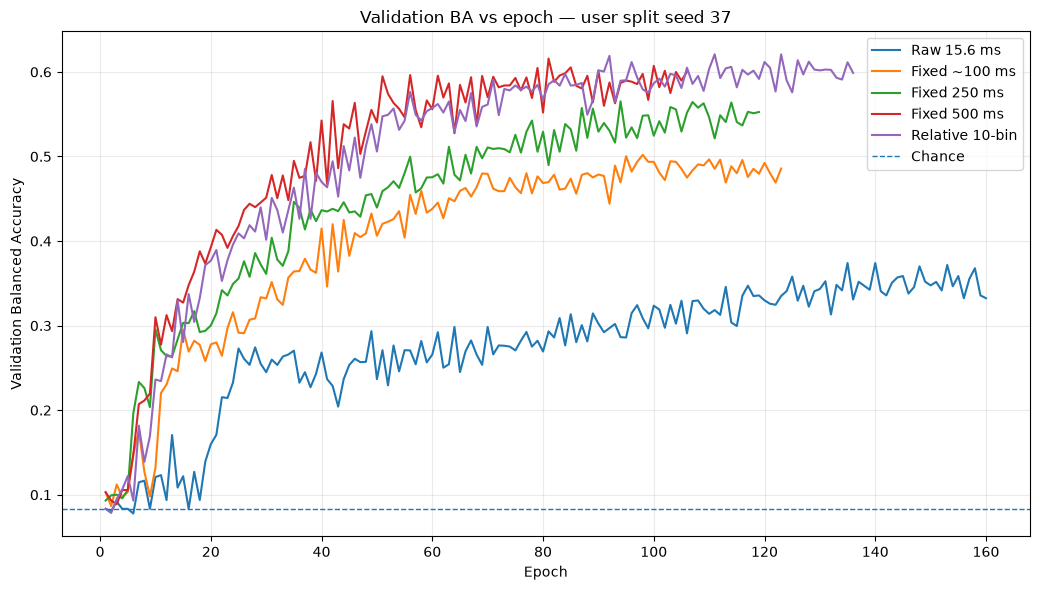

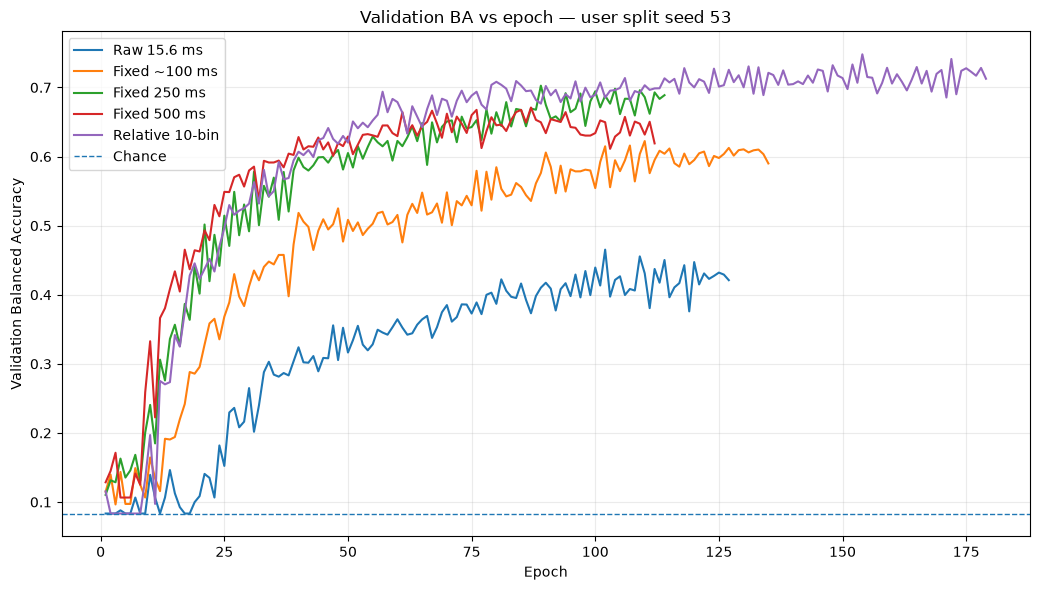

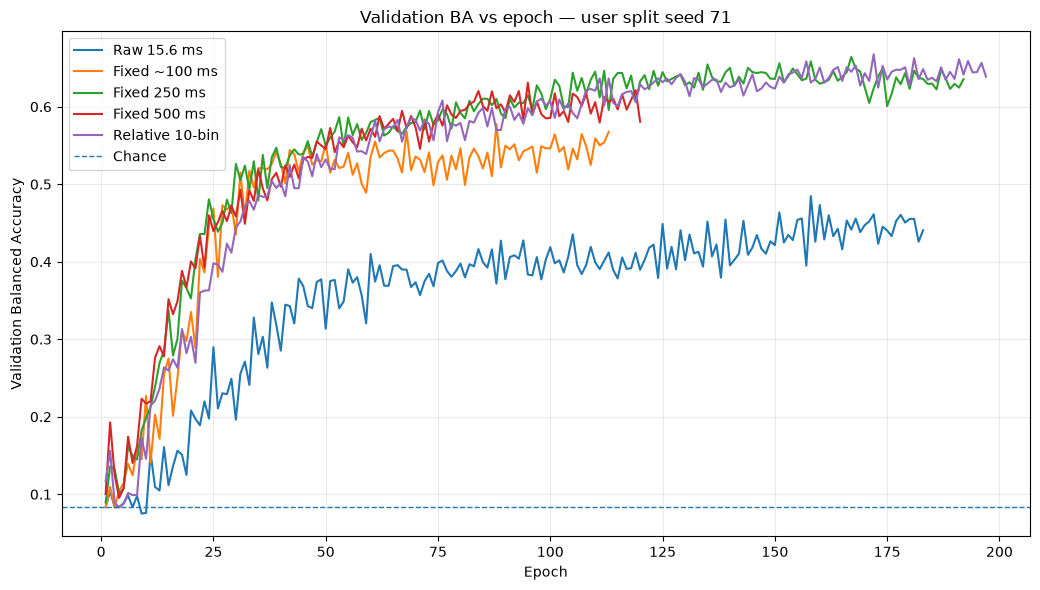

In [17]:
for split_seed in SPLIT_SEEDS:
    fig, ax = plt.subplots(figsize=(10.5, 6.0))
    sdf = training_history[training_history["split_seed"] == split_seed]
    for representation in representation_order:
        rdf = sdf[sdf["representation"] == representation].sort_values("epoch")
        ax.plot(
            rdf["epoch"],
            rdf["val_balanced_accuracy"],
            label=label_map.get(representation, representation).replace("\n", " "),
        )
    ax.axhline(1.0 / N_CLASSES, linestyle="--", linewidth=1.0, label="Chance")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Balanced Accuracy")
    ax.set_title(f"Validation BA vs epoch — user split seed {split_seed}")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 17. Per-split table

Use this table to check whether a conclusion is consistent across users rather than being driven by one favorable split.


In [18]:
per_split_view = paired[[
    "split_seed",
    "representation",
    "test_balanced_accuracy_linear",
    "test_balanced_accuracy_cnn",
    "test_ba_gain_cnn_minus_linear",
    "best_epoch",
]].copy()

display(
    per_split_view.sort_values(["split_seed", "representation"])
)


,split_seed,representation,test_balanced_accuracy_linear,test_balanced_accuracy_cnn,test_ba_gain_cnn_minus_linear,best_epoch
1,11,fixed_100ms,0.519553,0.571541,0.051988,144
2,11,fixed_250ms,0.683184,0.513426,-0.169758,79
3,11,fixed_500ms,0.647699,0.627751,-0.019948,96
0,11,raw_timestep,0.287241,0.261976,-0.025266,27
4,11,relative_10bin,0.817824,0.623672,-0.194152,138
6,23,fixed_100ms,0.482232,0.436773,-0.045459,102
7,23,fixed_250ms,0.537563,0.534661,-0.002902,142
8,23,fixed_500ms,0.571126,0.560927,-0.010199,78
5,23,raw_timestep,0.328467,0.325240,-0.003227,171
9,23,relative_10bin,0.683647,0.548691,-0.134956,149


## Interpretation guide

The experiment is designed to distinguish **representation quality** from **temporal-modeling capacity**.

- **CNN ≈ Linear on a representation:** flattening already exposes most of the usable class information to a global linear decision rule; local nonlinear temporal motif extraction adds little.
- **CNN > Linear:** the representation contains additional local temporal/compositional structure that a linear readout does not exploit.
- **Raw CNN > Raw Linear by a large margin:** exact 64 Hz timing may be poorly linearly aligned across users, while a translation-tolerant local temporal model can still recover useful motifs.
- **Fixed 100/250/500 ms CNN peak:** supports an intermediate absolute temporal scale for local motif composition. Because the CNN kernel spans three bins per layer, do not equate the winning bin duration directly with `tau_syn`.
- **Relative 10-bin CNN remains strongest:** gesture-progress alignment still provides the most robust representation across unseen users, even after allowing local nonlinear temporal modeling.
- **Fixed CNN catches/exceeds relative 10-bin:** absolute-time bins contain enough local sequence structure that a temporal model can compensate for some of the cross-user timing variability that hurts the Linear probe.

### Architectural caveat

The same CNN architecture is intentionally reused across representations, but `kernel_size=3` corresponds to different physical durations at different bin sizes. Therefore this notebook compares **representation + shared discrete CNN architecture**, not equalized physical receptive fields. A later control can equalize receptive field in milliseconds if needed.
